# K-mer frequency spectra across alphabets and ksizes

Data: `~/data/kmerseek-kmer-spectra/`, produced by `nextflow-runs/kmer-spectra/main.nf` running `kmerseek index --kmer-stats-out` over Swiss-Prot for every (alphabet, ksize) combo. Each file is a k-mer occurrence histogram (how many distinct k-mers occur 1x, 2x, 3x, ... times across the proteome), with summary stats in a `#`-prefixed header line.

In [1]:
import gzip
import re
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

DATA_DIR = Path.home() / "data" / "kmerseek-kmer-spectra"
FIG_DIR = Path(".")

plt.rcParams["figure.dpi"] = 100


In [2]:
HEADER_RE = re.compile(
    r"total_kmers=(?P<total_kmers>\d+)\s+"
    r"unique_kmers=(?P<unique_kmers>\d+)\s+"
    r"mean_seqs_per_kmer=(?P<mean_seqs_per_kmer>[\d.]+)\s+"
    r"median_seqs_per_kmer=(?P<median_seqs_per_kmer>[\d.]+)\s+"
    r"moltype=(?P<moltype>\S+)\s+"
    r"ksize=(?P<ksize>\d+)"
)


def parse_header(path: Path) -> dict:
    with gzip.open(path, "rt") as fh:
        first_line = fh.readline()
    m = HEADER_RE.search(first_line)
    if m is None:
        raise ValueError(f"Could not parse header of {path}: {first_line!r}")
    d = m.groupdict()
    return {
        "moltype": d["moltype"],
        "ksize": int(d["ksize"]),
        "total_kmers": int(d["total_kmers"]),
        "unique_kmers": int(d["unique_kmers"]),
        "mean_seqs_per_kmer": float(d["mean_seqs_per_kmer"]),
        "median_seqs_per_kmer": float(d["median_seqs_per_kmer"]),
    }


def load_histogram(path: Path) -> pl.DataFrame:
    return pl.read_csv(path, comment_prefix="#")


spectrum_files = sorted(DATA_DIR.glob("sprot.*.spectrum.csv.gz"))
print(f"Found {len(spectrum_files)} spectrum files")
spectrum_files[:3]


Found 134 spectrum files


[PosixPath('/Users/olga/data/kmerseek-kmer-spectra/sprot.dayhoff.k10.spectrum.csv.gz'),
 PosixPath('/Users/olga/data/kmerseek-kmer-spectra/sprot.dayhoff.k11.spectrum.csv.gz'),
 PosixPath('/Users/olga/data/kmerseek-kmer-spectra/sprot.dayhoff.k12.spectrum.csv.gz')]

In [3]:
summary_df = pl.DataFrame([parse_header(p) for p in spectrum_files]).sort(["moltype", "ksize"])

# Redundancy: what fraction of all k-mer occurrences collapse onto fewer unique k-mers.
# Lower unique_kmers/total_kmers at fixed ksize means the alphabet compresses more.
summary_df = summary_df.with_columns(
    (pl.col("unique_kmers") / pl.col("total_kmers")).alias("unique_fraction")
)

print(summary_df.shape)
summary_df


(134, 7)


moltype,ksize,total_kmers,unique_kmers,mean_seqs_per_kmer,median_seqs_per_kmer,unique_fraction
str,i64,i64,i64,f64,f64,f64
"""dayhoff""",10,172339558,14848084,11.6069,3.0,0.086156
"""dayhoff""",11,172084420,33976195,5.0649,2.0,0.197439
"""dayhoff""",12,171752076,58988034,2.9116,1.0,0.343449
"""dayhoff""",13,171378861,80110845,2.1393,1.0,0.467449
"""dayhoff""",14,170983997,92775115,1.843,1.0,0.542595
…,…,…,…,…,…,…
"""protein""",11,179343169,118428118,1.5144,1.0,0.660344
"""protein""",12,178888285,120695883,1.4821,1.0,0.6747
"""protein""",13,178429587,122660599,1.4547,1.0,0.687445


## Figure 1: unique k-mer count vs ksize, by alphabet

How fast does the observed k-mer vocabulary grow with ksize for each alphabet? A reduced alphabet (HP, dayhoff) should saturate at far fewer unique k-mers than the full 20-letter protein alphabet at the same ksize. `hp_shuffled_control` is *not* a sequence-shuffle — it applies the real, unmodified Swiss-Prot sequences to a randomly scrambled amino-acid-to-H/P partition (h: `ADGKLMQRWY`, p: `CEFHINPSTV`, frozen for reproducibility in kmerseek's `hp_alphabets.rs`), as opposed to the biologically-motivated partitions (Lehninger, Thomas-Dill, Kyte-Doolittle, PBotC) used by the other HP variants.</cell id="4c8e4757">

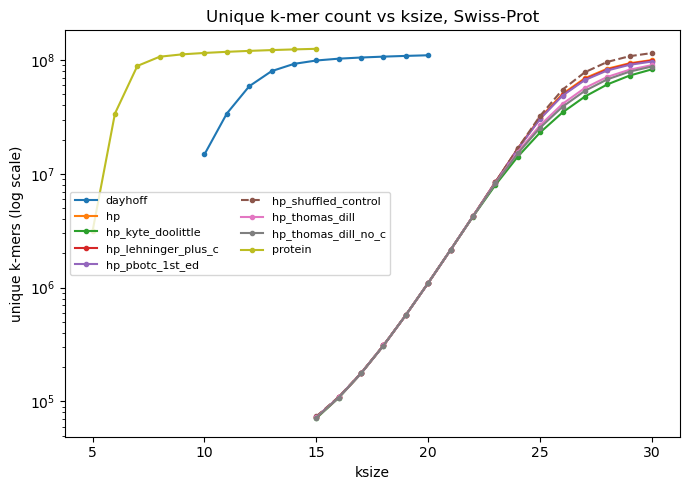

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
for moltype, group in summary_df.group_by("moltype", maintain_order=True):
    moltype = moltype[0]
    g = group.sort("ksize")
    linestyle = "--" if moltype == "hp_shuffled_control" else "-"
    ax.plot(g["ksize"], g["unique_kmers"], marker="o", markersize=3, linestyle=linestyle, label=moltype)

ax.set_yscale("log")
ax.set_xlabel("ksize")
ax.set_ylabel("unique k-mers (log scale)")
ax.set_title("Unique k-mer count vs ksize, Swiss-Prot")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(FIG_DIR / "24_unique_kmers_vs_ksize_by_alphabet.png", dpi=150, bbox_inches="tight")


## Figure 2: mean k-mer degeneracy vs ksize, by alphabet

`mean_seqs_per_kmer` is `total_kmers / unique_kmers` — the average number of proteome occurrences sharing each distinct k-mer. Higher values mean more collisions/degeneracy at that ksize. This is the number that matters for search specificity: an alphabet+ksize combo with high mean degeneracy will have more spurious k-mer matches between unrelated sequences.

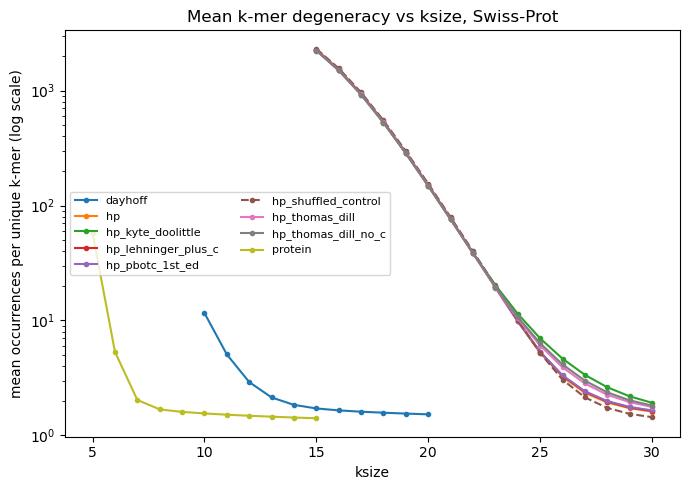

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
for moltype, group in summary_df.group_by("moltype", maintain_order=True):
    moltype = moltype[0]
    g = group.sort("ksize")
    linestyle = "--" if moltype == "hp_shuffled_control" else "-"
    ax.plot(g["ksize"], g["mean_seqs_per_kmer"], marker="o", markersize=3, linestyle=linestyle, label=moltype)

ax.set_yscale("log")
ax.set_xlabel("ksize")
ax.set_ylabel("mean occurrences per unique k-mer (log scale)")
ax.set_title("Mean k-mer degeneracy vs ksize, Swiss-Prot")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(FIG_DIR / "24_mean_degeneracy_vs_ksize_by_alphabet.png", dpi=150, bbox_inches="tight")


## Figure 3: HP-family degeneracy relative to the scrambled-partition null

For each HP variant (`hp`, `hp_kyte_doolittle`, `hp_lehninger_plus_c`, `hp_thomas_dill`, `hp_thomas_dill_no_c`, `hp_pbotc_1st_ed`), divide its `mean_seqs_per_kmer` by `hp_shuffled_control`'s at the same ksize. `hp_shuffled_control` is the real Swiss-Prot sequences encoded with a randomly scrambled amino-acid-to-H/P partition (see Figure 1), not a sequence-order shuffle — so this ratio isolates the effect of *which* partition is used, holding the real sequence and its real internal correlations fixed.

**Caution reading this ratio** (worked out in the section after Figure 4): `mean_seqs_per_kmer` here is not raw occurrence count. kmerseek's `--kmer-stats-out` increments a k-mer's count once per *protein* whose MinHash sketch contains it (a document-frequency-style count, from `index.rs` in the `kmer-frequency-histogram` branch), not once per sliding window. A ratio below 1 therefore does not mean "real HP patterning is no more repetitive than chance" — see below for what it actually reflects.</cell id="87cc693c">

shape: (6, 2)
┌─────────────────────┬──────────────────────────────┐
│ moltype             ┆ degeneracy_ratio_vs_shuffled │
│ ---                 ┆ ---                          │
│ str                 ┆ f64                          │
╞═════════════════════╪══════════════════════════════╡
│ hp                  ┆ 0.971056                     │
│ hp_kyte_doolittle   ┆ 0.955772                     │
│ hp_lehninger_plus_c ┆ 0.971523                     │
│ hp_pbotc_1st_ed     ┆ 0.963734                     │
│ hp_thomas_dill      ┆ 0.959302                     │
│ hp_thomas_dill_no_c ┆ 0.956819                     │
└─────────────────────┴──────────────────────────────┘


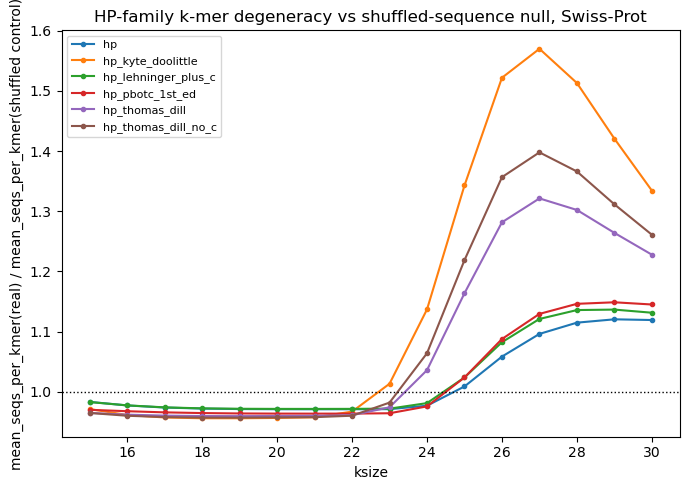

In [6]:
hp_variants = [
    "hp",
    "hp_kyte_doolittle",
    "hp_lehninger_plus_c",
    "hp_thomas_dill",
    "hp_thomas_dill_no_c",
    "hp_pbotc_1st_ed",
]

control = summary_df.filter(pl.col("moltype") == "hp_shuffled_control").select(
    "ksize", pl.col("mean_seqs_per_kmer").alias("control_mean_seqs_per_kmer")
)

ratio_df = (
    summary_df.filter(pl.col("moltype").is_in(hp_variants))
    .join(control, on="ksize", how="inner")
    .with_columns((pl.col("mean_seqs_per_kmer") / pl.col("control_mean_seqs_per_kmer")).alias("degeneracy_ratio_vs_shuffled"))
    .sort(["moltype", "ksize"])
)

fig, ax = plt.subplots(figsize=(7, 5))
for moltype, group in ratio_df.group_by("moltype", maintain_order=True):
    moltype = moltype[0]
    g = group.sort("ksize")
    ax.plot(g["ksize"], g["degeneracy_ratio_vs_shuffled"], marker="o", markersize=3, label=moltype)

ax.axhline(1.0, color="black", linestyle=":", linewidth=1)
ax.set_xlabel("ksize")
ax.set_ylabel("mean_seqs_per_kmer(real) / mean_seqs_per_kmer(shuffled control)")
ax.set_title("HP-family k-mer degeneracy vs shuffled-sequence null, Swiss-Prot")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "24_hp_degeneracy_ratio_vs_shuffled_control.png", dpi=150, bbox_inches="tight")

print(ratio_df.filter(pl.col("ksize") == 19).select("moltype", "degeneracy_ratio_vs_shuffled"))


## Figure 4: occurrence-histogram shape at ksize=19

The full histogram (occurrences -> n_kmers with that occurrence count) shows the *shape* of degeneracy, not just its mean. ksize=19 is available for every HP-family alphabet and is the designated best ksize for `hp_pbotc_1st_ed`. Note `hp_shuffled_control` is the scrambled-partition null described in Figure 1, not a sequence shuffle.

The x-axis, "occurrences," is a document-frequency count (see the section below): how many distinct proteins' MinHash sketches contain that k-mer, not how many times it appears across all sliding windows.</cell id="d86c6365">

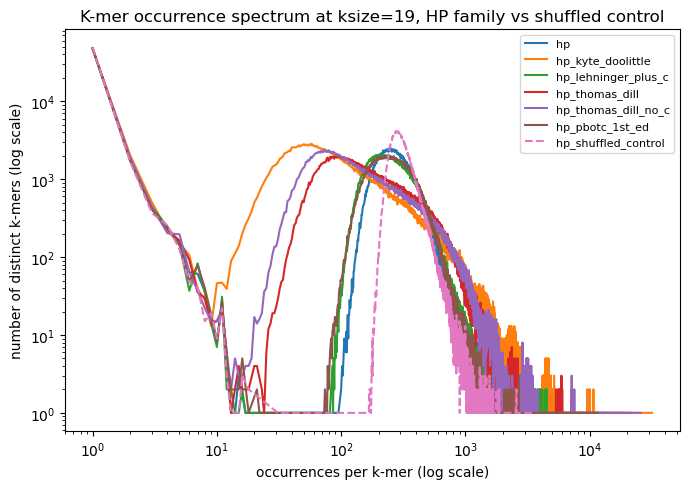

In [7]:
ksize_fixed = 19
moltypes_fixed = hp_variants + ["hp_shuffled_control"]

path_by_moltype = {parse_header(p)["moltype"]: p for p in spectrum_files if parse_header(p)["ksize"] == ksize_fixed}

fig, ax = plt.subplots(figsize=(7, 5))
for moltype in moltypes_fixed:
    path = path_by_moltype.get(moltype)
    if path is None:
        continue
    hist = load_histogram(path).sort("occurrences")
    linestyle = "--" if moltype == "hp_shuffled_control" else "-"
    ax.plot(hist["occurrences"], hist["n_kmers"], linestyle=linestyle, label=moltype)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("occurrences per k-mer (log scale)")
ax.set_ylabel("number of distinct k-mers (log scale)")
ax.set_title(f"K-mer occurrence spectrum at ksize={ksize_fixed}, HP family vs shuffled control")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / f"24_occurrence_histogram_k{ksize_fixed}_hp_family_vs_control.png", dpi=150, bbox_inches="tight")


## Why `hp_pbotc_1st_ed` (and every named HP alphabet) sits below the shuffled-partition null

Figure 3 shows every biologically-motivated HP variant with a degeneracy ratio below 1 at ksize <= 22. That looks backwards if you read "shuffled_control" as a "no structure" null: real, biologically patterned sequences should be *more* repetitive than an arbitrary control, not less.

The resolution is in how `total_kmers` is defined, traced from kmerseek's `kmer-frequency-histogram` branch (`index.rs`, `save_inverted_index`): for every protein, it takes that protein's MinHash sketch — a *deduplicated set* of the protein's distinct k-mers — and increments each k-mer's counter once per protein that contains it. So:

- `total_kmers` = sum over proteins of (number of *distinct* k-mers in that protein), not sum of all sliding windows.
- `unique_kmers` (proteome-wide distinct k-mer vocabulary) is nearly identical across all 7 alphabets at a given ksize (574k-576k at k=19 — see the table below), because with ~170M k-mer instances against only 2^19 = 524,288 possible binary strings, virtually every reachable pattern gets hit at least once regardless of composition.
- So `mean_seqs_per_kmer = total_kmers / unique_kmers` is driven almost entirely by `total_kmers`, i.e. by how many *distinct* k-mers survive deduplication within individual proteins.

A biologically-motivated H/P partition groups amino acids that really do co-occur in local structural contexts (hydrophobic cores, polar loops, etc.), so encoding a real protein with it produces longer runs of the same symbol -- fewer distinct k-mers survive per protein. A scrambled partition breaks those real local correlations apart, so the *same* real sequences look more locally diverse under it, and more distinct k-mers survive per protein.

That means the ratio-below-1 result is not "real HP patterning is unremarkable" -- it is the opposite: it is what you'd expect if the named partitions are capturing real, compressible local structure that an arbitrary partition does not. This is verified directly below from raw sequences (independent of any inference from the header stats).

In [8]:
# H/P tables, sourced directly from kmerseek:
#   hp                    -- REFERENCE_sourmash/src/core/src/encodings.rs, HPTABLE (sourmash built-in)
#   all other variants     -- src/rust/hp_alphabets.rs (kmerseek-kmer-frequency-histogram branch)
HP_TABLES = {
    "hp": {**{r: "h" for r in "AFGILMPVWY"}, **{r: "p" for r in "CDEHKNQRST"}},
    "hp_thomas_dill": {**{r: "h" for r in "ACFILMVWY"}, **{r: "p" for r in "DEGHKNPQRST"}},
    "hp_kyte_doolittle": {**{r: "h" for r in "ACFILMV"}, **{r: "p" for r in "DEGHKNPQRSTWY"}},
    "hp_thomas_dill_no_c": {**{r: "h" for r in "AFILMVWY"}, **{r: "p" for r in "CDEGHKNPQRST"}},
    "hp_lehninger_plus_c": {**{r: "h" for r in "ACFGILMPVWY"}, **{r: "p" for r in "DEHKNQRST"}},
    "hp_pbotc_1st_ed": {**{r: "h" for r in "ACFILMPVWY"}, **{r: "p" for r in "DEGHKNQRST"}},
    "hp_shuffled_control": {**{r: "h" for r in "ADGKLMQRWY"}, **{r: "p" for r in "CEFHINPSTV"}},
}

k19_table = summary_df.filter((pl.col("ksize") == 19) & (pl.col("moltype").is_in(HP_TABLES))).sort(
    "total_kmers", descending=True
)
print(k19_table.select("moltype", "total_kmers", "unique_kmers", "mean_seqs_per_kmer"))


shape: (7, 4)
┌─────────────────────┬─────────────┬──────────────┬────────────────────┐
│ moltype             ┆ total_kmers ┆ unique_kmers ┆ mean_seqs_per_kmer │
│ ---                 ┆ ---         ┆ ---          ┆ ---                │
│ str                 ┆ i64         ┆ i64          ┆ f64                │
╞═════════════════════╪═════════════╪══════════════╪════════════════════╡
│ hp_shuffled_control ┆ 171291308   ┆ 575716       ┆ 297.5274           │
│ hp_lehninger_plus_c ┆ 166142286   ┆ 574778       ┆ 289.0547           │
│ hp                  ┆ 166067392   ┆ 574795       ┆ 288.9159           │
│ hp_pbotc_1st_ed     ┆ 164818686   ┆ 574807       ┆ 286.7374           │
│ hp_thomas_dill      ┆ 164006170   ┆ 574616       ┆ 285.4187           │
│ hp_thomas_dill_no_c ┆ 163563131   ┆ 574551       ┆ 284.6799           │
│ hp_kyte_doolittle   ┆ 163324414   ┆ 574341       ┆ 284.3684           │
└─────────────────────┴─────────────┴──────────────┴────────────────────┘


### Direct verification: per-protein k-mer diversity fraction

For a random sample of real Swiss-Prot proteins, encode each one under all 7 tables and compute `n_distinct_kmers / n_sliding_windows` per protein -- exactly the quantity kmerseek's MinHash-based `total_kmers` count is built from, computed here independently and directly from sequence, not inferred from the spectrum files. If the mechanism above is right, `hp_shuffled_control` should have the *highest* mean diversity fraction (least within-protein repetition) and the alphabets that group real physicochemically-correlated residues together should sit measurably lower.

In [9]:
import random

FASTA_PATH = Path.home() / "data" / "uniprot" / "uniprot_sprot.fasta.gz"

seqs = []
with gzip.open(FASTA_PATH, "rt") as fh:
    chunks = []
    for line in fh:
        line = line.strip()
        if line.startswith(">"):
            if chunks:
                seqs.append("".join(chunks))
            chunks = []
        else:
            chunks.append(line)
    if chunks:
        seqs.append("".join(chunks))

print(f"total proteins in Swiss-Prot: {len(seqs)}")

random.seed(0)
k = 19
sample = random.sample([s for s in seqs if len(s) >= k + 1], 5000)

diversity_records = []
for name, table in HP_TABLES.items():
    fractions = []
    for s in sample:
        encoded = "".join(table.get(aa, "X") for aa in s)
        n_windows = len(encoded) - k + 1
        n_distinct = len({encoded[i : i + k] for i in range(n_windows)})
        fractions.append(n_distinct / n_windows)
    diversity_records.append(
        {"moltype": name, "mean_diversity_fraction": sum(fractions) / len(fractions), "n_proteins": len(fractions)}
    )

diversity_df = pl.DataFrame(diversity_records).sort("mean_diversity_fraction", descending=True)
print(diversity_df)


total proteins in Swiss-Prot: 572970


shape: (7, 3)
┌─────────────────────┬─────────────────────────┬────────────┐
│ moltype             ┆ mean_diversity_fraction ┆ n_proteins │
│ ---                 ┆ ---                     ┆ ---        │
│ str                 ┆ f64                     ┆ i64        │
╞═════════════════════╪═════════════════════════╪════════════╡
│ hp_shuffled_control ┆ 0.998528                ┆ 5000       │
│ hp_pbotc_1st_ed     ┆ 0.997351                ┆ 5000       │
│ hp                  ┆ 0.997237                ┆ 5000       │
│ hp_lehninger_plus_c ┆ 0.99699                 ┆ 5000       │
│ hp_thomas_dill      ┆ 0.996449                ┆ 5000       │
│ hp_thomas_dill_no_c ┆ 0.996097                ┆ 5000       │
│ hp_kyte_doolittle   ┆ 0.995137                ┆ 5000       │
└─────────────────────┴─────────────────────────┴────────────┘


Pearson r=0.8754, p=0.0098  (n=7 alphabets)


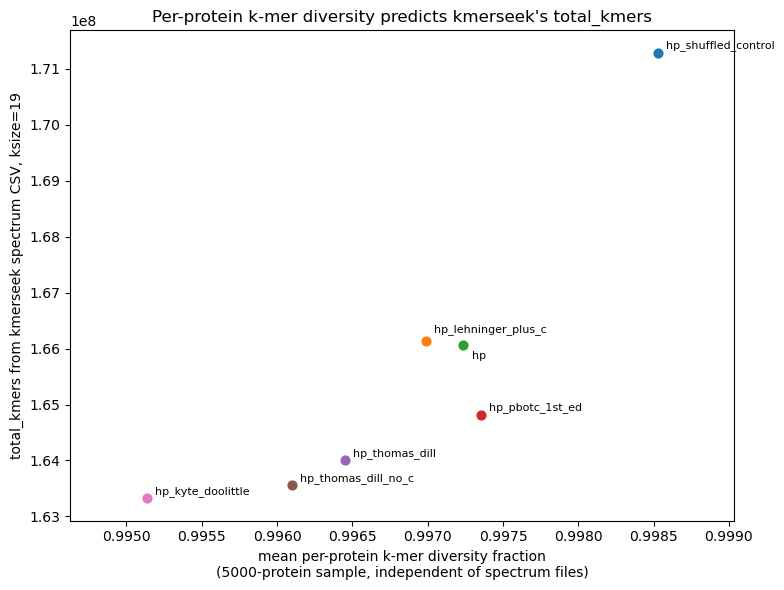

In [10]:
from scipy import stats

merged = diversity_df.join(k19_table.select("moltype", "total_kmers"), on="moltype")
r, p = stats.pearsonr(merged["mean_diversity_fraction"], merged["total_kmers"])
print(f"Pearson r={r:.4f}, p={p:.4f}  (n={merged.shape[0]} alphabets)")

fig, ax = plt.subplots(figsize=(8, 6))
offsets = {
    "hp": (6, -10),
    "hp_lehninger_plus_c": (6, 6),
}
for row in merged.iter_rows(named=True):
    ax.scatter(row["mean_diversity_fraction"], row["total_kmers"], s=40)
    dx, dy = offsets.get(row["moltype"], (6, 3))
    ax.annotate(
        row["moltype"],
        (row["mean_diversity_fraction"], row["total_kmers"]),
        fontsize=8,
        xytext=(dx, dy),
        textcoords="offset points",
    )

ax.set_xlabel("mean per-protein k-mer diversity fraction\n(5000-protein sample, independent of spectrum files)")
ax.set_ylabel("total_kmers from kmerseek spectrum CSV, ksize=19")
ax.set_title("Per-protein k-mer diversity predicts kmerseek's total_kmers")
ax.margins(x=0.15)
fig.tight_layout()
fig.savefig(FIG_DIR / "24_diversity_fraction_vs_total_kmers.png", dpi=150, bbox_inches="tight")
